# Run multiVI on gastrulation multiome

In [1]:
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sc.set_figure_params(figsize=(8, 8))

Global seed set to 0
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/pytorch_lightning/utilities/warnings.py:53: LightningDeprecationWarning: pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6 and will be removed in v1.8. Use the equivalent function from the pytorch_lightning.utilities.rank_zero module instead.
  new_rank_zero_deprecation(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/pytorch_lightning/utilities/warnings.py:58: LightningDeprecationWarning: The `pytorch_lightning.loggers.base.rank_zero_experiment` is deprecated in v1.7 and will be removed in v1.9. Please use `pytorch_lightning.loggers.logger.rank_zero_experiment` instead.
  return new_rank_zero_deprecation(*args, **kwargs)


In [2]:
basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/epiblast_blood/'

In [3]:
adata = sc.read_h5ad(basedir + 'anndata_multiVI.h5ad')

In [4]:
variables = pd.read_csv(basedir + "variable.csv")

In [5]:
variables = variables.set_index('ID', drop=False)

In [6]:
adata.var = variables

In [7]:
adata.X = adata.X.tocsr()

In [8]:
adata_mvi = adata

In [9]:
print(adata_mvi.shape)
sc.pp.filter_genes(adata_mvi, min_cells=int(adata_mvi.shape[0] * 0.01))
print(adata_mvi.shape)

(12686, 32500)
(12686, 32426)


In [10]:
adata_mvi

AnnData object with n_obs × n_vars = 12686 × 32426
    obs: 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage', 'doublet_score', 'celltype', 'celltype.score', 'closest.cell'
    var: 'ID', 'modality', 'n_cells'

In [24]:
scvi.model.MULTIVI.setup_anndata(adata_mvi, 
                                 batch_key='stage',
                                 categorical_covariate_keys=["sample"])

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [25]:
mvi = scvi.model.MULTIVI(
    adata_mvi,
    n_genes=(adata_mvi.var['modality']=='Gene Expression').sum(),
    n_regions=(adata_mvi.var['modality']=='Peaks').sum(),
)
mvi.view_anndata_setup()

/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/torch/nn/init.py:405: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Anndata setup with scvi-tools version 0.19.0.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'stage',
│   'size_factor_key': None,
│   'categorical_covariate_keys': ['sample'],
│   'continuous_covariate_keys': None,
│   'protein_expression_obsm_key': None,
│   'protein_names_uns_key': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   5   │
│         n_cells          │ 12686 │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 32426 │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         ind_x          │           adata.obs['_indices']            │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

                  batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['stage'] │    E7.5    │          0          │
│                    │   E7.75    │          1          │
│                    │    E8.0    │          2          │
│                    │    E8.5    │          3          │
│                    │   E8.75    │          4          │
└────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

                  batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['stage'] │    E7.5    │          0          │
│                    │   E7.75    │          1          │
│                    │    E8.0    │          2          │
│                    │    E8.5    │          3          │
│                    │   E8.75    │          4          │
└────────────────────┴────────────┴─────────────────────┘

          extra_categorical_covs State Registry           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ E7.5_rep1  │          0          │
│                     │ E7.5_rep2  │          1          │
│                     │ E7.75_rep1 │          2          │
│                     │ E8.0_rep1  │          3          │
│                     │ E8.0_rep2  │          4          │
│                     │ E8.5_rep1  │          5          │
│                     │ E8.5_rep2  │          6          │
│                     │ E8.75_rep1 │          7          │
│                     │ E8.75_rep2 │          8          │
│                     │            │                     │
└─────────────────────┴────────────┴─────────────────────┘

In [26]:
mvi.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/pytorch_lightning/trainer/configuration_validator.py:267: LightningDeprecationWarning: The `Callback.on_epoch_end` hook was deprecated in v1.6 and will be removed in v1.8. Please use `Callback.on_<train/validation/test>_epoch_end` instead.
  rank_zero_deprecation(


Epoch 268/500:  54%|█████▎    | 268/500 [3:22:23<2:55:12, 45.31s/it, loss=7.08e+03, v_num=1]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 14648.244. Signaling Trainer to stop.


In [27]:
mvi.save(basedir + 'multiVI_model/')

In [11]:
mvi = scvi.model.MULTIVI.load(basedir +  "multiVI_model/", adata=adata)

INFO     File                                                                                                      
         /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/epiblast_blood/multiVI_mod
         el/model.pt already downloaded                                                                            


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/torch/nn/init.py:405: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [12]:
adata_mvi.obsm["MultiVI_latent"] = mvi.get_latent_representation()
sc.pp.neighbors(adata_mvi, use_rep="MultiVI_latent")
sc.tl.umap(adata_mvi, min_dist=0.2)

/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


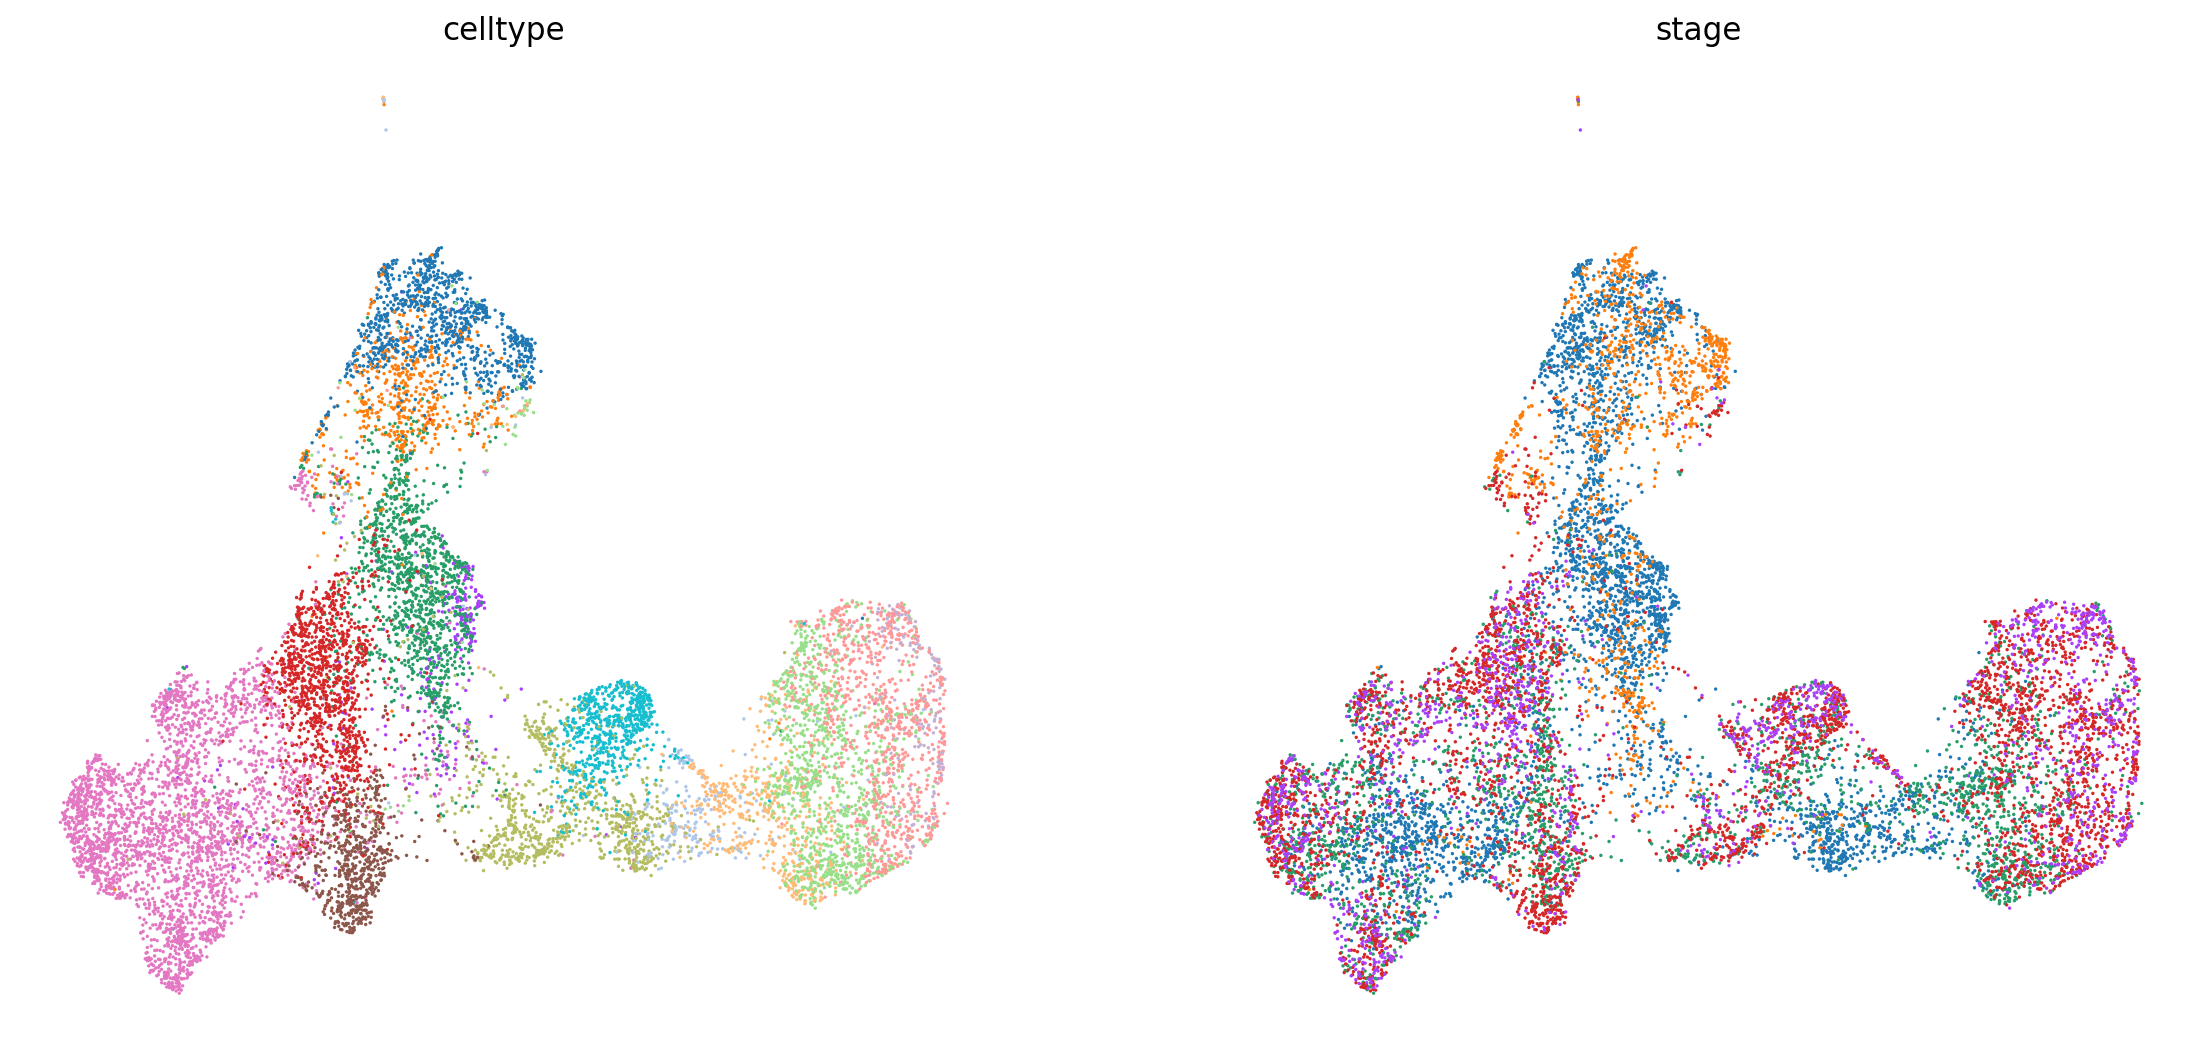

In [13]:
sc.pl.umap(
    adata,
    color=["celltype", "stage"],
    frameon=False,
    ncols=2, legend_loc='none'
)

In [14]:
umap = pd.DataFrame(adata.obsm['X_umap'])
latent = pd.DataFrame(adata.obsm['MultiVI_latent'])

umap.to_csv(basedir + 'multiVI_umap.csv')
latent.to_csv(basedir + 'multiVI_latent.csv')

In [15]:
imputed_expression = mvi.get_normalized_expression()

In [37]:
adata_mvi.var.tail(20)

,ID,modality,n_cells
ID,,,
chrX:162727307-162727907,chrX:162727307-162727907,Peaks,2213
chrX:162748586-162749186,chrX:162748586-162749186,Peaks,1642
chrX:162759956-162760556,chrX:162759956-162760556,Peaks,5359
chrX:162760572-162761172,chrX:162760572-162761172,Peaks,2814
chrX:162888132-162888732,chrX:162888132-162888732,Peaks,2525
chrX:163908677-163909277,chrX:163908677-163909277,Peaks,5253
chrX:163909280-163909880,chrX:163909280-163909880,Peaks,1907
chrX:163958395-163958995,chrX:163958395-163958995,Peaks,3302
chrX:164419321-164419921,chrX:164419321-164419921,Peaks,4734


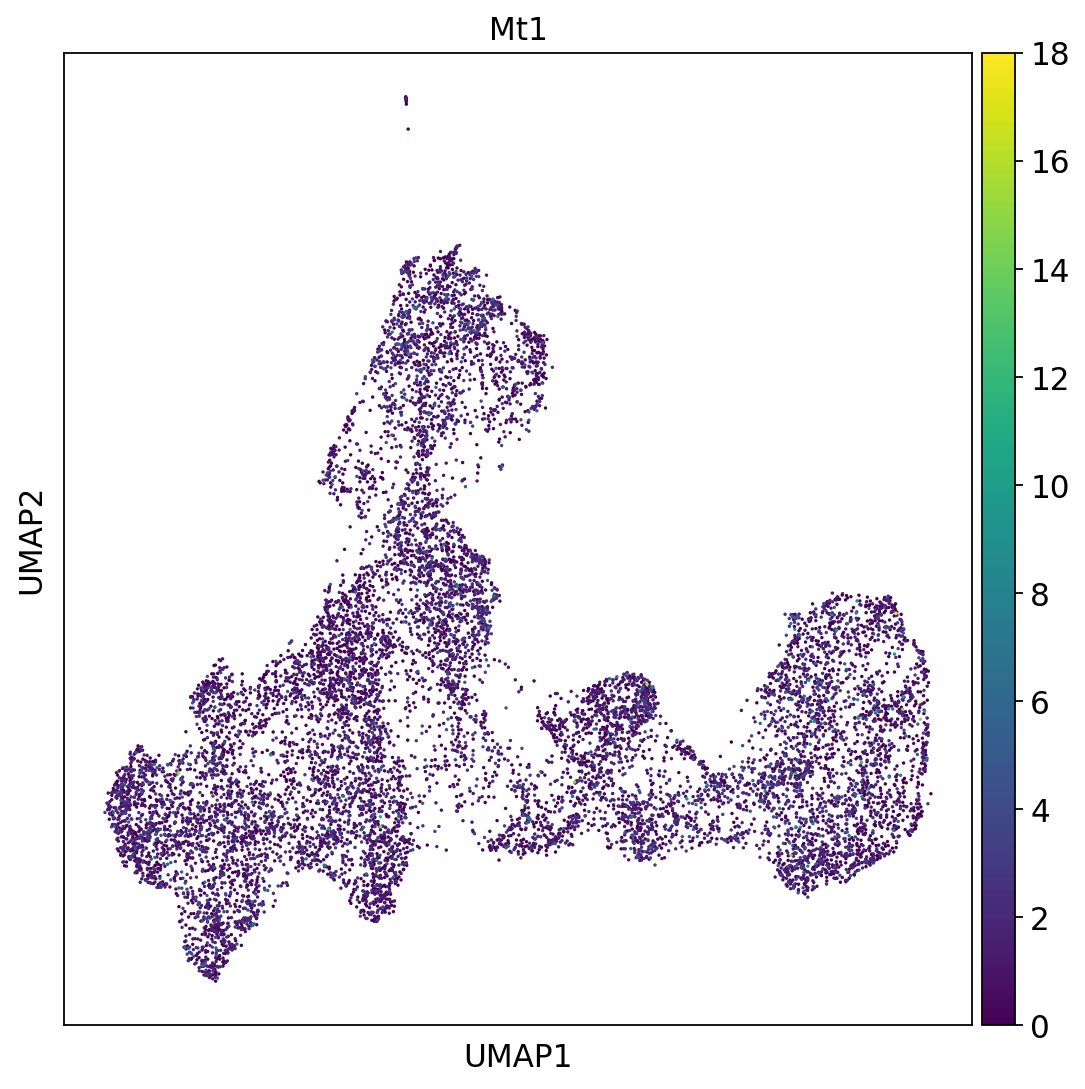

In [47]:
sc.pl.umap(adata_mvi, color='Mt1')

In [36]:
gene_idx = np.where(adata_mvi.var.index == "Mt1")[0]
adata_mvi.obs["imputed"] = imputed_expression.iloc[:, gene_idx]
sc.pl.umap(adata_mvi, color='imputed')

IndexError: positional indexers are out-of-bounds

In [40]:
imputed_accessibility = mvi.get_accessibility_estimates()

In [45]:
imputed_accessibility

ID,chr1:3482876-3483476,chr1:3670515-3671115,chr1:3671511-3672111,chr1:4491836-4492436,chr1:4492444-4493044,chr1:4493400-4494000,chr1:4495884-4496484,chr1:4571501-4572101,chr1:4774993-4775593,chr1:4785409-4786009,...,chrX:166170050-166170650,chrX:166440439-166441039,chrX:166510184-166510784,chrX:167101821-167102421,chrX:167208228-167208828,chrX:167208867-167209467,chrX:168672333-168672933,chrX:168773293-168773893,chrX:169106170-169106770,chrX:169320126-169320726
E7.5_rep1#AAACAGCCATCCTGAA-1,0.046563,0.395152,0.665894,0.316969,0.317894,0.353258,0.207051,0.671501,0.017585,0.615981,...,0.466397,0.544720,0.551652,0.029126,0.113846,0.292885,0.252073,0.086179,0.060057,0.497779
E7.5_rep1#AAACAGCCATGCTATG-1,0.658275,0.700208,0.799382,0.442701,0.688355,0.701754,0.411740,0.563082,0.007732,0.619118,...,0.490731,0.664965,0.614403,0.013049,0.103355,0.311496,0.246567,0.007914,0.004330,0.531504
E7.5_rep1#AAACATGCAGGATAAC-1,0.005290,0.167582,0.405700,0.178899,0.190467,0.285837,0.327357,0.503831,0.041848,0.428346,...,0.389522,0.464834,0.514254,0.025347,0.057317,0.189653,0.163804,0.096633,0.280020,0.521242
E7.5_rep1#AAACCGGCAACCCTAA-1,0.212738,0.698349,0.758053,0.431799,0.696030,0.599348,0.269701,0.718468,0.015323,0.667164,...,0.606917,0.694060,0.667241,0.025787,0.198555,0.357175,0.300439,0.018052,0.012374,0.632863
E7.5_rep1#AAACCGGCAACCTAAT-1,0.011272,0.287972,0.569468,0.353552,0.376638,0.478595,0.410905,0.641609,0.047715,0.427515,...,0.569156,0.543943,0.618781,0.089039,0.136904,0.417676,0.192439,0.204791,0.302045,0.563373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E8.75_rep2#TTTGCGACATTAGGTT-1,0.003669,0.245136,0.185632,0.131222,0.070281,0.054305,0.115310,0.321581,0.018830,0.902764,...,0.738961,0.811374,0.871453,0.011329,0.199106,0.640030,0.486303,0.023589,0.310482,0.911528
E8.75_rep2#TTTGCGGAGTAAGAAC-1,0.003489,0.144171,0.088260,0.102991,0.069691,0.023633,0.048500,0.125019,0.022916,0.845151,...,0.601303,0.647057,0.883513,0.005712,0.141299,0.440198,0.480537,0.008887,0.332645,0.831688
E8.75_rep2#TTTGGCTGTAGTTGGC-1,0.002576,0.273776,0.214459,0.168771,0.095890,0.045789,0.166094,0.287580,0.011925,0.732253,...,0.570464,0.581690,0.651329,0.009993,0.110372,0.497424,0.327021,0.014198,0.282904,0.791510
E8.75_rep2#TTTGTGGCATCTTGAG-1,0.012002,0.182090,0.167307,0.092053,0.049667,0.042639,0.042015,0.290272,0.049850,0.968830,...,0.853405,0.942271,0.984646,0.013214,0.294387,0.650337,0.567420,0.015172,0.357422,0.978104


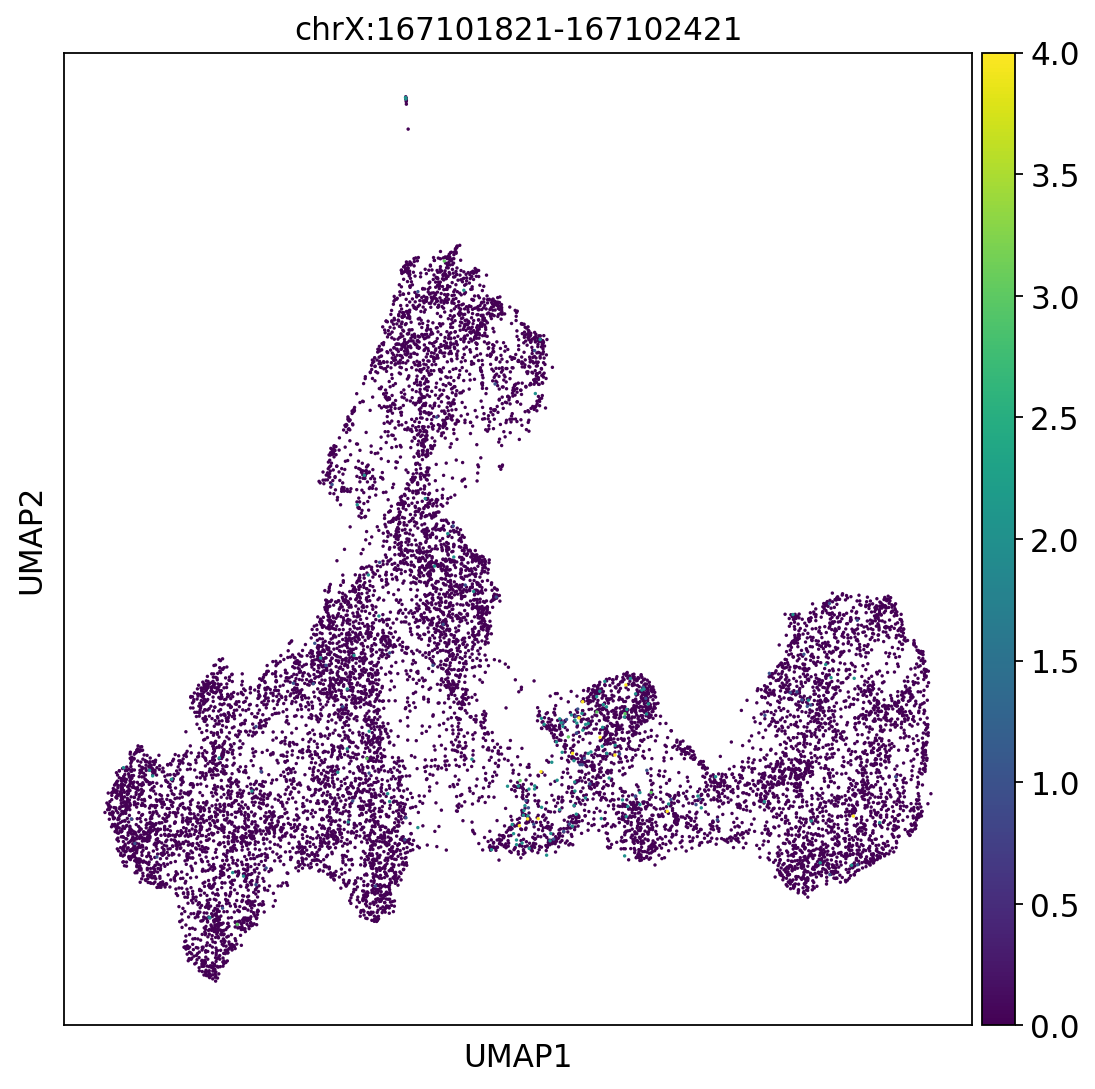

In [52]:
sc.pl.umap(adata_mvi, color='chrX:167101821-167102421')

In [57]:
np.where(adata_mvi.var.index == "chrX:167101821-167102421")[0]

array([32419])

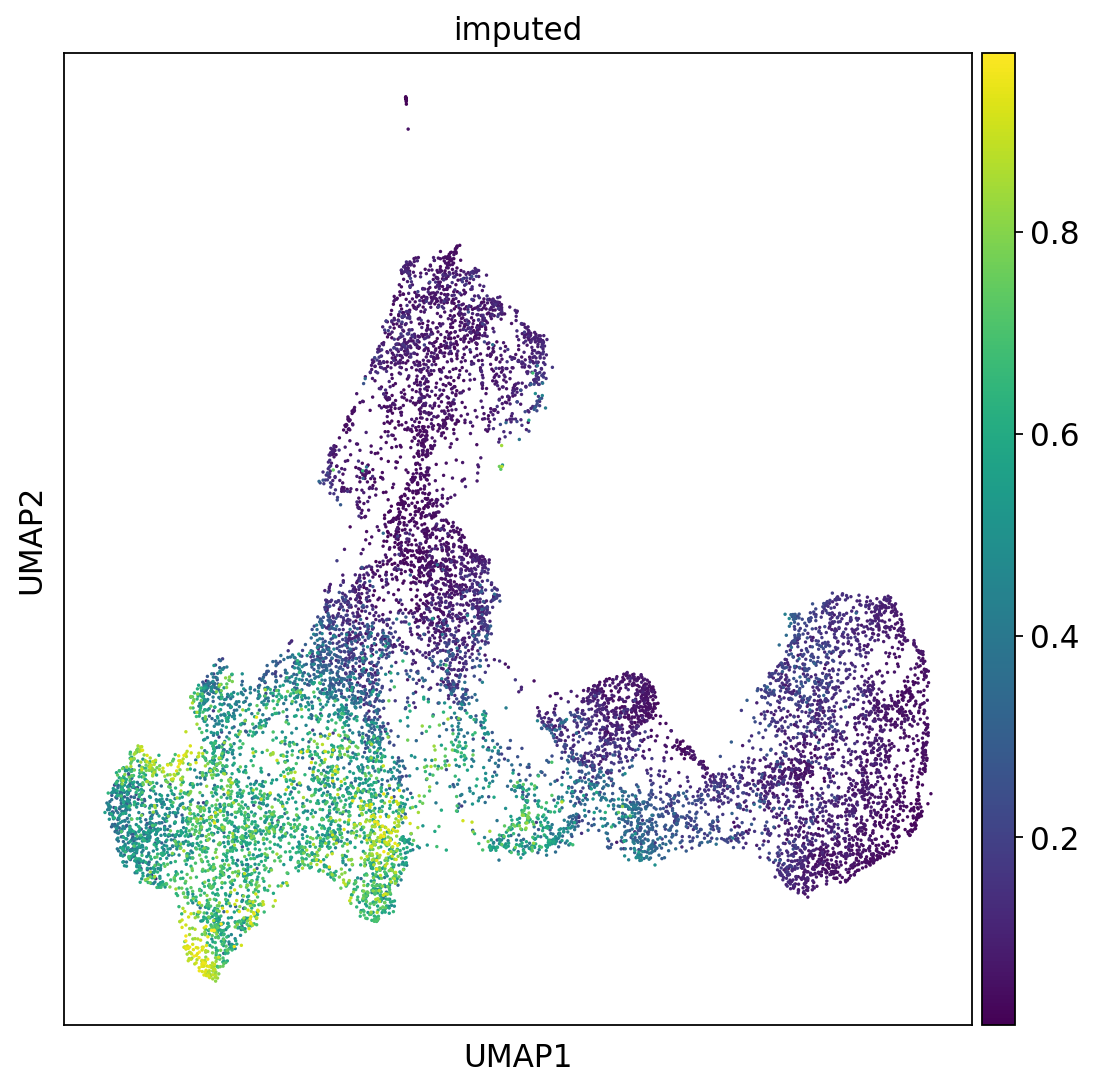

In [76]:
peak_idx = np.where(adata_mvi.var.index == "chrX:167101821-167102421")[0]
adata_mvi.obs["imputed"] = imputed_accessibility.iloc[:, 1235]
sc.pl.umap(adata_mvi, color='imputed')